In [5]:
import os, argparse, time
import matplotlib.pyplot as plt
import numpy as np
from plotting import new_figure, save_figure
from ode.utils import load_from_config
from scipy.constants import c as c_cnst
from scipy import interpolate
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm


data = "GW_M=1.00e-06_q=1.00_20260420_151640"
data_dir = "data"
results_dir = "results/"

theta = 45.0
phi = 0.0

Q = 1e5
Ns = 100
geometry = "cylindrical"         # "rectangular", "cylindrical", "spherical"

modes = [
    {"mode_fam": "TM", "mode_par": "b", "mode_ind": (0, 1, 0)},
    {"mode_fam": "TE", "mode_par": "a", "mode_ind": (1, 1, 1)},
    {"mode_fam": "TE", "mode_par": "b", "mode_ind": (1, 1, 1)},
    {"mode_fam": "TM", "mode_par": "b", "mode_ind": (0, 1, 1)},
    {"mode_fam": "TE", "mode_par": "a", "mode_ind": (2, 1, 1)},
    {"mode_fam": "TE", "mode_par": "b", "mode_ind": (2, 1, 1)},
    {"mode_fam": "TE", "mode_par": "a", "mode_ind": (1, 1, 2)},
    {"mode_fam": "TE", "mode_par": "b", "mode_ind": (1, 1, 2)},
    {"mode_fam": "TM", "mode_par": "a", "mode_ind": (1, 1, 0)},
    {"mode_fam": "TM", "mode_par": "b", "mode_ind": (1, 1, 0)},
    {"mode_fam": "TM", "mode_par": "b", "mode_ind": (0, 1, 2)},
    {"mode_fam": "TM", "mode_par": "a", "mode_ind": (1, 1, 1)},
    {"mode_fam": "TM", "mode_par": "b", "mode_ind": (1, 1, 1)},
    {"mode_fam": "TE", "mode_par": "b", "mode_ind": (0, 1, 1)},
    {"mode_fam": "TE", "mode_par": "a", "mode_ind": (2, 1, 2)},
    {"mode_fam": "TE", "mode_par": "b", "mode_ind": (2, 1, 2)},
    {"mode_fam": "TM", "mode_par": "a", "mode_ind": (1, 1, 2)},
    {"mode_fam": "TM", "mode_par": "b", "mode_ind": (1, 1, 2)},
    {"mode_fam": "TE", "mode_par": "b", "mode_ind": (0, 1, 2)},
    {"mode_fam": "TE", "mode_par": "a", "mode_ind": (1, 1, 3)},
    {"mode_fam": "TE", "mode_par": "b", "mode_ind": (1, 1, 3)},
    {"mode_fam": "TM", "mode_par": "a", "mode_ind": (2, 1, 0)},
    {"mode_fam": "TM", "mode_par": "b", "mode_ind": (2, 1, 0)},
    {"mode_fam": "TM", "mode_par": "b", "mode_ind": (0, 1, 3)},
    {"mode_fam": "TM", "mode_par": "a", "mode_ind": (2, 1, 1)},
    {"mode_fam": "TM", "mode_par": "b", "mode_ind": (2, 1, 1)},
    {"mode_fam": "TM", "mode_par": "b", "mode_ind": (0, 2, 0)},
    {"mode_fam": "TE", "mode_par": "a", "mode_ind": (1, 2, 1)},
    {"mode_fam": "TE", "mode_par": "b", "mode_ind": (1, 2, 1)},
    {"mode_fam": "TE", "mode_par": "a", "mode_ind": (2, 1, 3)},
    {"mode_fam": "TE", "mode_par": "b", "mode_ind": (2, 1, 3)},
    {"mode_fam": "TM", "mode_par": "b", "mode_ind": (0, 2, 1)},
    {"mode_fam": "TM", "mode_par": "a", "mode_ind": (2, 1, 2)},
    {"mode_fam": "TM", "mode_par": "b", "mode_ind": (2, 1, 2)},
    {"mode_fam": "TM", "mode_par": "a", "mode_ind": (1, 1, 3)},
    {"mode_fam": "TM", "mode_par": "b", "mode_ind": (1, 1, 3)},
    {"mode_fam": "TE", "mode_par": "b", "mode_ind": (0, 1, 3)},
    {"mode_fam": "TE", "mode_par": "a", "mode_ind": (1, 2, 2)},
    {"mode_fam": "TE", "mode_par": "b", "mode_ind": (1, 2, 2)},
    {"mode_fam": "TM", "mode_par": "b", "mode_ind": (0, 2, 2)},
]

def build_file_path(m, geometry, theta, phi, data, filename="amplitude_package.npz", base_path="."):
    mode_ind_str = ",".join(map(str, m["mode_ind"]))
    dir_name1 = f'{geometry}_{m["mode_fam"]}{m["mode_par"]}_{mode_ind_str}_theta={theta}_phi={phi}_Ns={Ns}'
    dir_name2 = f"DATA_{data}"
    return Path(base_path) / results_dir / dir_name1 / dir_name2 / filename

def build_config_path(m, geometry, theta, phi, filename="run_config.json", base_path="."):
    mode_ind_str = ",".join(map(str, m["mode_ind"]))
    dir_name1 = f'{geometry}_{m["mode_fam"]}{m["mode_par"]}_{mode_ind_str}_theta={theta}_phi={phi}_Ns={Ns}'
    return Path(base_path) / results_dir / dir_name1

loaded_modes = {}
loaded_omegas = {}

for m in modes:
    fpath = build_file_path(m, geometry, theta, phi, data)
    cpath = build_config_path(m, geometry, theta, phi)
    omega, _ = load_from_config(cpath)
    key = f'{m["mode_fam"]}{m["mode_par"]}_{",".join(map(str, m["mode_ind"]))}'
    loaded_omegas[key] = omega
    loaded_modes[key] = np.load(fpath)




In [6]:
print(loaded_modes.keys())
print(loaded_modes["TMb_1,1,3"].files)
print(loaded_omegas["TMb_1,1,3"])

dict_keys(['TMb_0,1,0', 'TEa_1,1,1', 'TEb_1,1,1', 'TMb_0,1,1', 'TEa_2,1,1', 'TEb_2,1,1', 'TEa_1,1,2', 'TEb_1,1,2', 'TMa_1,1,0', 'TMb_1,1,0', 'TMb_0,1,2', 'TMa_1,1,1', 'TMb_1,1,1', 'TEb_0,1,1', 'TEa_2,1,2', 'TEb_2,1,2', 'TMa_1,1,2', 'TMb_1,1,2', 'TEb_0,1,2', 'TEa_1,1,3', 'TEb_1,1,3', 'TMa_2,1,0', 'TMb_2,1,0', 'TMb_0,1,3', 'TMa_2,1,1', 'TMb_2,1,1', 'TMb_0,2,0', 'TEa_1,2,1', 'TEb_1,2,1', 'TEa_2,1,3', 'TEb_2,1,3', 'TMb_0,2,1', 'TMa_2,1,2', 'TMb_2,1,2', 'TMa_1,1,3', 'TMb_1,1,3', 'TEb_0,1,3', 'TEa_1,2,2', 'TEb_1,2,2', 'TMb_0,2,2'])
['t', 'c', 'cD', 'b', 'U']
61001219580.18068


In [7]:
all_t = []
all_f = []
all_u = []

for key, data in loaded_modes.items():
    t_ns = data["t"] * 1e9
    U = np.abs(data["U"])
    omega = loaded_omegas[key]

    f_ghz = omega / (2 * np.pi) / 1e9

    f_arr = np.full_like(t_ns, f_ghz, dtype=float)

    mask = np.isfinite(t_ns) & np.isfinite(U) & (U > 0)
    all_t.append(t_ns[mask])
    all_f.append(f_arr[mask])
    all_u.append(U[mask])

all_t = np.concatenate(all_t)
all_f = np.concatenate(all_f)
all_u = np.concatenate(all_u)

In [8]:
target_t_ns = 100.0

print(f"U at t = {target_t_ns:.1f} ns (interpolated per mode):\n")
for key in sorted(loaded_modes.keys(), key=lambda k: loaded_omegas[k]):
    mode_npz = loaded_modes[key]
    t_ns_mode = mode_npz["t"] * 1e9
    U_mode = mode_npz["U"]

    # sort by time for safe interpolation
    s = np.argsort(t_ns_mode)
    t_sorted = t_ns_mode[s]
    U_sorted = U_mode[s]

    if not (t_sorted[0] <= target_t_ns <= t_sorted[-1]):
        print(f"{key:10s}  f={loaded_omegas[key]/(2*np.pi)/1e9:7.3f} GHz  out of range")
        continue

    if np.iscomplexobj(U_sorted):
        U_at_t = np.interp(target_t_ns, t_sorted, U_sorted.real) + 1j * np.interp(
            target_t_ns, t_sorted, U_sorted.imag
        )
    else:
        U_at_t = np.interp(target_t_ns, t_sorted, U_sorted)

    print(
        f"{key:10s}  f={loaded_omegas[key]/(2*np.pi)/1e9:7.3f} GHz  "
        f"U={U_at_t:.6e}  |U|={np.abs(U_at_t):.6e}"
    )

U at t = 100.0 ns (interpolated per mode):

TMb_0,1,0   f=  2.295 GHz  out of range
TEa_1,1,1   f=  3.475 GHz  out of range
TEb_1,1,1   f=  3.475 GHz  out of range
TMa_1,1,0   f=  3.656 GHz  out of range
TMb_1,1,0   f=  3.656 GHz  out of range
TMb_0,1,1   f=  3.775 GHz  out of range
TEa_2,1,1   f=  4.181 GHz  out of range
TEb_2,1,1   f=  4.181 GHz  out of range
TMa_1,1,1   f=  4.728 GHz  out of range
TMb_1,1,1   f=  4.728 GHz  out of range
TEb_0,1,1   f=  4.728 GHz  out of range
TMa_2,1,0   f=  4.901 GHz  out of range
TMb_2,1,0   f=  4.901 GHz  out of range
TMb_0,2,0   f=  5.268 GHz  out of range
TMa_2,1,1   f=  5.745 GHz  out of range
TMb_2,1,1   f=  5.745 GHz  out of range
TEa_1,2,1   f=  5.905 GHz  out of range
TEb_1,2,1   f=  5.905 GHz  out of range
TMb_0,2,1   f=  6.061 GHz  out of range
TEa_1,1,2   f=  6.248 GHz  out of range
TEb_1,1,2   f=  6.248 GHz  out of range
TMb_0,1,2   f=  6.420 GHz  out of range
TEa_2,1,2   f=  6.667 GHz  out of range
TEb_2,1,2   f=  6.667 GHz  out of ra

/var/folders/4w/tsf6hqg15s51q56dbr12bnk40000gp/T/ipykernel_42898/513675475.py:115: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = copy.copy(cm.get_cmap(CMAP))


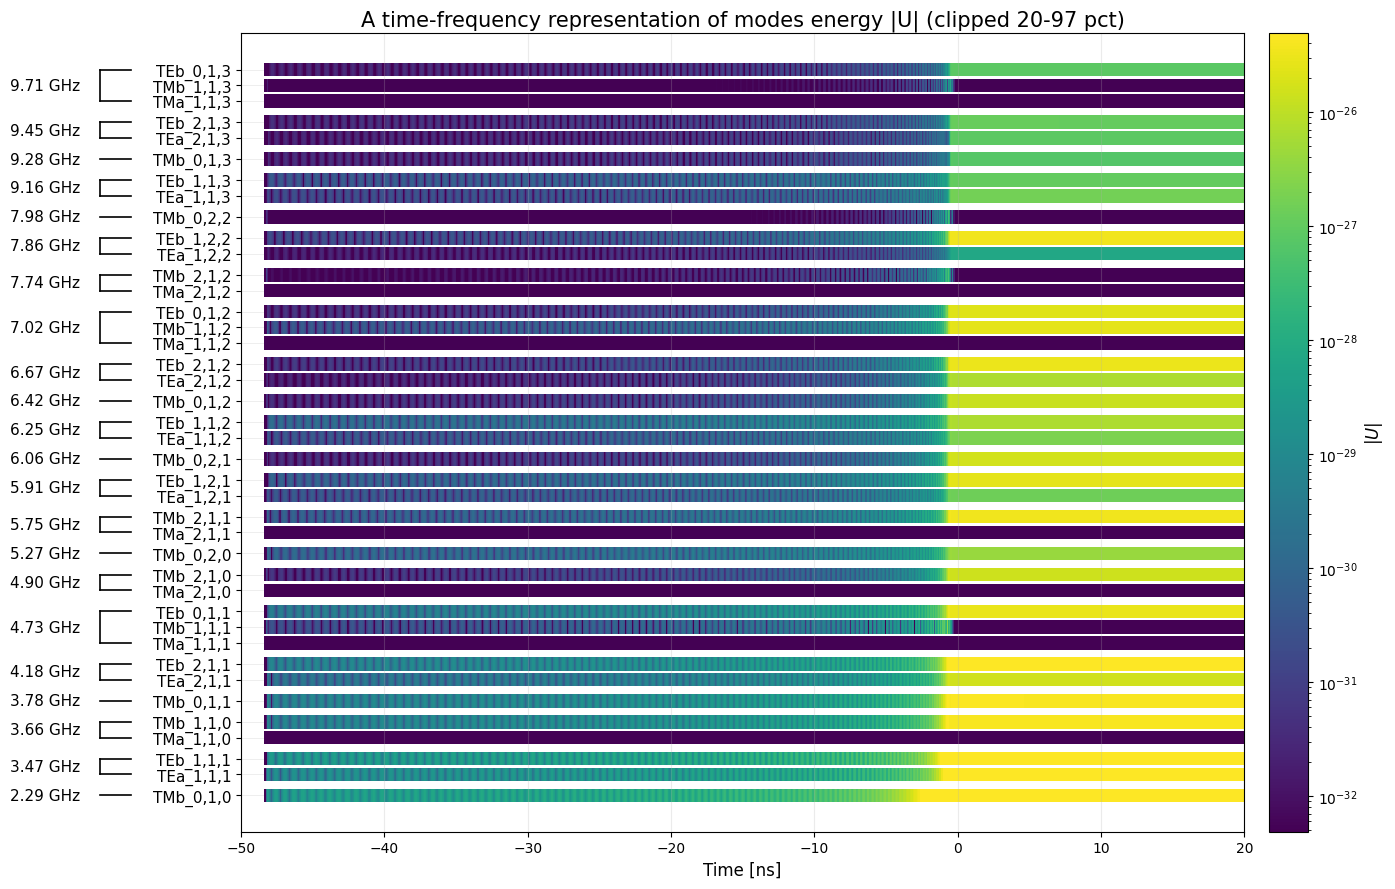

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.transforms as transforms
import matplotlib.cm as cm
import copy

# --- settings ---
FIGSIZE = (17,9)
MARKER_SIZE = 95
MARKER = "s"
CMAP = "viridis"
KEEP_EVERY = 10

TMIN_NS, TMAX_NS = -50, 20
ABS_LO_PERCENTILE, ABS_HI_PERCENTILE = 20, 97

SAME_FREQ_GAP = 1.5
DIFF_FREQ_GAP = 2
FREQ_TOL_GHZ = 0.0005   # 5 MHz

# --- sort modes by frequency ---
mode_items = sorted(loaded_modes.items(), key=lambda kv: loaded_omegas[kv[0]])

mode_names = []
mode_freqs = []
mode_y_positions = []

prev_freq, y = None, 0.0
for key, _ in mode_items:
    omega = loaded_omegas[key]
    freq = omega / (2*np.pi) / 1e9

    if prev_freq is not None:
        same = abs(freq - prev_freq) < FREQ_TOL_GHZ
        y += SAME_FREQ_GAP if same else DIFF_FREQ_GAP

    mode_names.append(str(key))
    mode_freqs.append(freq)
    mode_y_positions.append(y)
    prev_freq = freq

# --- build frequency groups ---
freq_groups = []

start = 0
for i in range(1, len(mode_freqs) + 1):
    is_break = (
        i == len(mode_freqs)
        or abs(mode_freqs[i] - mode_freqs[i - 1]) >= FREQ_TOL_GHZ
    )
    if is_break:
        y0 = mode_y_positions[start]
        y1 = mode_y_positions[i - 1]
        yc = 0.5 * (y0 + y1)
        freq_groups.append({
            "freq": mode_freqs[start],
            "start": start,
            "end": i - 1,
            "y0": y0,
            "y1": y1,
            "yc": yc,
        })
        start = i

# --- collect plotted points ---
all_t, all_y, all_c = [], [], []

for (key, data), yrow in zip(mode_items, mode_y_positions):
    t_ns = np.asarray(data["t"]) * 1e9
    U = np.abs(np.asarray(data["U"]))

    # keep zeros; only reject non-finite values
    m = np.isfinite(t_ns) & np.isfinite(U)

    if TMIN_NS is not None:
        m &= (t_ns >= TMIN_NS)
    if TMAX_NS is not None:
        m &= (t_ns <= TMAX_NS)

    t_ns, U = t_ns[m], U[m]
    if t_ns.size == 0:
        continue

    t_ns, U = t_ns[::KEEP_EVERY], U[::KEEP_EVERY]
    all_t.append(t_ns)
    all_y.append(np.full(t_ns.shape, yrow, dtype=float))
    all_c.append(U)

if not all_t:
    raise ValueError("No data points to plot after filtering/downsampling.")

all_t = np.concatenate(all_t)
all_y = np.concatenate(all_y)
all_c = np.concatenate(all_c)

# --- color normalization (compute from positive values only) ---
vals = all_c[np.isfinite(all_c) & (all_c > 0)]
if vals.size == 0:
    raise ValueError("No positive finite |U| values available for LogNorm.")

vmin = np.percentile(vals, ABS_LO_PERCENTILE)
vmax = np.percentile(vals, ABS_HI_PERCENTILE)
vmin = max(vmin, np.min(vals))
if vmax <= vmin:
    vmax = np.max(vals)

norm = colors.LogNorm(vmin=vmin, vmax=vmax)

# replace zeros by a tiny value below vmin so they use the colormap's "under" color
all_c_plot = all_c.copy()
all_c_plot[all_c_plot <= 0] = vmin / 10.0

# make the "under" color equal to the darkest/lowest color of the colormap
cmap = copy.copy(cm.get_cmap(CMAP))
cmap.set_under(cmap(0.0))

title = f"A time-frequency representation of modes energy |U| (clipped {ABS_LO_PERCENTILE}-{ABS_HI_PERCENTILE} pct)"

# --- plot ---
fig, ax = plt.subplots(figsize=FIGSIZE)
sc = ax.scatter(
    all_t, all_y, c=all_c_plot, cmap=cmap, norm=norm,
    s=MARKER_SIZE, marker=MARKER, linewidths=0
)

ax.set_yticks(mode_y_positions)
ax.set_yticklabels(mode_names, fontsize=11)

for yy in mode_y_positions:
    ax.axhline(yy, color="k", lw=0.4, alpha=0.12, zorder=0)

ax.grid(axis="x", alpha=0.25)
ax.set_xlabel("Time [ns]", fontsize=12)
ax.set_title(title, fontsize=15)

if TMIN_NS is not None or TMAX_NS is not None:
    ax.set_xlim(
        TMIN_NS if TMIN_NS is not None else all_t.min(),
        TMAX_NS if TMAX_NS is not None else all_t.max()
    )

# --- draw combined frequency labels on the far left ---
trans = transforms.blended_transform_factory(ax.transAxes, ax.transData)

x_text = -0.16
x_line = -0.14
x_hook = -0.11

for g in freq_groups:
    ax.text(
        x_text, g["yc"], f'{g["freq"]:.2f} GHz',
        transform=trans,
        ha="right", va="center",
        fontsize=11, fontweight="normal", color="black",
        clip_on=False
    )
        
    if g["end"] > g["start"]:
    # bracket for multi-row group
        ax.plot([x_line, x_line], [g["y0"], g["y1"]],
                transform=trans, color="black", lw=1.2, clip_on=False)
        ax.plot([x_line, x_hook], [g["y0"], g["y0"]],
                transform=trans, color="black", lw=1.2, clip_on=False)
        ax.plot([x_line, x_hook], [g["y1"], g["y1"]],
                transform=trans, color="black", lw=1.2, clip_on=False)
    else:
        # short connector line for single-row group
        ax.plot([x_line, x_hook], [g["yc"], g["yc"]],
                transform=trans, color="black", lw=1.2, clip_on=False)

cbar = plt.colorbar(sc, ax=ax, pad=0.02)
cbar.set_label(r"$|U|$", fontsize=12)

plt.tight_layout()
fig.subplots_adjust(left=0.28)

plt.show()

/var/folders/4w/tsf6hqg15s51q56dbr12bnk40000gp/T/ipykernel_42898/2186674504.py:110: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = copy.copy(cm.get_cmap(CMAP))


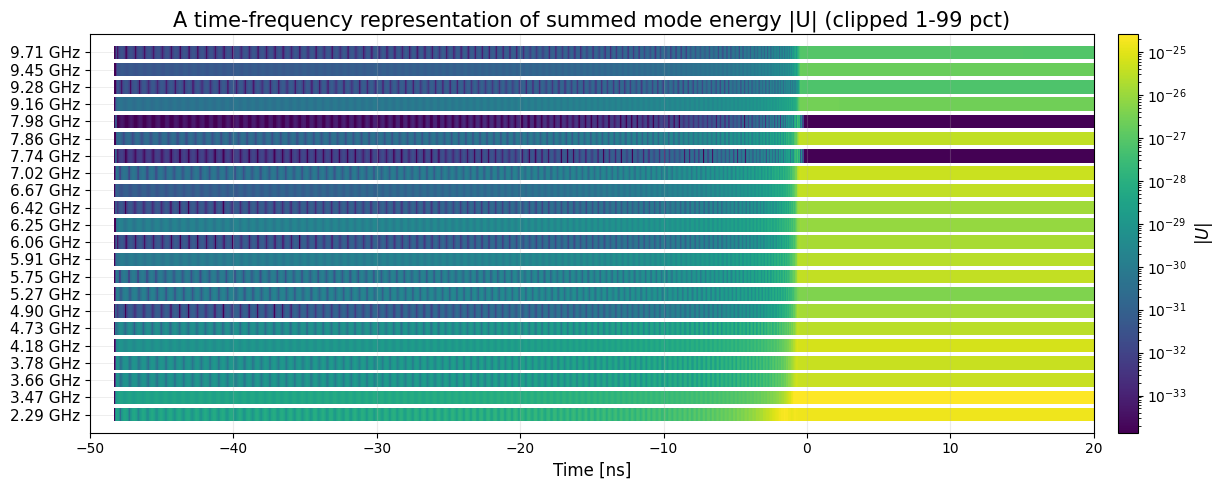

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.transforms as transforms
import matplotlib.cm as cm
import copy
from collections import defaultdict

# --- settings ---
FIGSIZE = (17,5)
MARKER_SIZE = 95
MARKER = "s"
CMAP = "viridis"
KEEP_EVERY = 10

TMIN_NS, TMAX_NS = -50, 20
ABS_LO_PERCENTILE, ABS_HI_PERCENTILE = 1, 99

#SAME_FREQ_GAP = 1.5
DIFF_FREQ_GAP = 0.3
FREQ_TOL_GHZ = 0.0005   # 5 MHz

# --- sort modes by frequency ---
mode_items = sorted(loaded_modes.items(), key=lambda kv: loaded_omegas[kv[0]])

# --- group modes by frequency and sum |U| ---
freq_groups_raw = []  # list of (freq, [keys], merged t->U dict)

for key, data in mode_items:
    omega = loaded_omegas[key]
    freq = omega / (2 * np.pi) / 1e9

    t_ns = np.asarray(data["t"]) * 1e9
    U = np.abs(np.asarray(data["U"]))
    m = np.isfinite(t_ns) & np.isfinite(U)
    if TMIN_NS is not None: m &= (t_ns >= TMIN_NS)
    if TMAX_NS is not None: m &= (t_ns <= TMAX_NS)
    t_ns, U = t_ns[m], U[m]

    # find matching group
    matched = None
    for g in freq_groups_raw:
        if abs(g["freq"] - freq) < FREQ_TOL_GHZ:
            matched = g
            break

    if matched is None:
        freq_groups_raw.append({"freq": freq, "keys": [str(key)], "t": t_ns, "U": U})
    else:
        matched["keys"].append(str(key))
        # sum U on the common time grid (interpolate onto existing grid)
        if matched["t"].size > 0 and t_ns.size > 0:
            U_interp = np.interp(matched["t"], t_ns, U, left=0.0, right=0.0)
            matched["U"] = matched["U"] + U_interp
        elif t_ns.size > 0:
            matched["t"] = t_ns
            matched["U"] = U

# --- assign y positions ---
row_labels = []
row_freqs = []
row_y_positions = []

prev_freq, y = None, 0.0
for g in freq_groups_raw:
    if prev_freq is not None:
        y += DIFF_FREQ_GAP
    g["y"] = y
    row_labels.append(" + ".join(g["keys"]))
    row_freqs.append(g["freq"])
    row_y_positions.append(y)
    prev_freq = g["freq"]


# --- collect plotted points ---
all_t, all_y, all_c = [], [], []

for g in freq_groups_raw:
    t_ns, U = g["t"], g["U"]
    if t_ns.size == 0:
        continue
    t_ns, U = t_ns[::KEEP_EVERY], U[::KEEP_EVERY]
    all_t.append(t_ns)
    all_y.append(np.full(t_ns.shape, g["y"], dtype=float))
    all_c.append(U)

if not all_t:
    raise ValueError("No data points to plot after filtering/downsampling.")

all_t = np.concatenate(all_t)
all_y = np.concatenate(all_y)
all_c = np.concatenate(all_c)

# --- color normalization ---
vals = all_c[np.isfinite(all_c) & (all_c > 0)]
if vals.size == 0:
    raise ValueError("No positive finite |U| values available for LogNorm.")

vmin = np.percentile(vals, ABS_LO_PERCENTILE)
vmax = np.percentile(vals, ABS_HI_PERCENTILE)
vmin = max(vmin, np.min(vals))
if vmax <= vmin:
    vmax = np.max(vals)

norm = colors.LogNorm(vmin=vmin, vmax=vmax)

all_c_plot = all_c.copy()
all_c_plot[all_c_plot <= 0] = vmin / 10.0

cmap = copy.copy(cm.get_cmap(CMAP))
cmap.set_under(cmap(0.0))

title = f"A time-frequency representation of summed mode energy |U| (clipped {ABS_LO_PERCENTILE}-{ABS_HI_PERCENTILE} pct)"

# --- plot ---
fig, ax = plt.subplots(figsize=FIGSIZE)
sc = ax.scatter(
    all_t, all_y, c=all_c_plot, cmap=cmap, norm=norm,
    s=MARKER_SIZE, marker=MARKER, linewidths=0
)

ax.set_yticks(row_y_positions)
#ax.set_yticklabels(row_labels, fontsize=11)

ax.set_yticklabels([f"{f:.2f} GHz" for f in row_freqs], fontsize=11)

for yy in row_y_positions:
    ax.axhline(yy, color="k", lw=0.4, alpha=0.12, zorder=0)

ax.grid(axis="x", alpha=0.25)
ax.set_xlabel("Time [ns]", fontsize=12)
ax.set_title(title, fontsize=15)

if TMIN_NS is not None or TMAX_NS is not None:
    ax.set_xlim(
        TMIN_NS if TMIN_NS is not None else all_t.min(),
        TMAX_NS if TMAX_NS is not None else all_t.max()
    )

# --- frequency labels on the far left ---
trans = transforms.blended_transform_factory(ax.transAxes, ax.transData)
x_text, x_line, x_hook = -0.16, -0.14, -0.11

# for g in freq_groups_raw:
#     ax.text(
#         x_text, g["y"], f'{g["freq"]:.2f} GHz',
#         transform=trans,
#         ha="right", va="center",
#         fontsize=11, color="black", clip_on=False
#     )
#     ax.plot([x_line, x_hook], [g["y"], g["y"]],
#             transform=trans, color="black", lw=1.2, clip_on=False)

cbar = plt.colorbar(sc, ax=ax, pad=0.02)
cbar.set_label(r"$|U|$", fontsize=12)

plt.tight_layout()
fig.subplots_adjust(left=0.28)

plt.show()